In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

In [3]:
market_df = pd.read_csv("/content/drive/MyDrive/Hiring Heat-map Datasets /market_sizing.csv")

segments_df = pd.read_csv("/content/drive/MyDrive/Hiring Heat-map Datasets /segmentation_ltv_results.csv")

finance_df = pd.read_excel("/content/drive/MyDrive/Hiring Heat-map Datasets /Financial_KPI_Tracker.xlsx")

## **Chart 1 – Revenue vs TAM (Growth + Market Opportunity)**

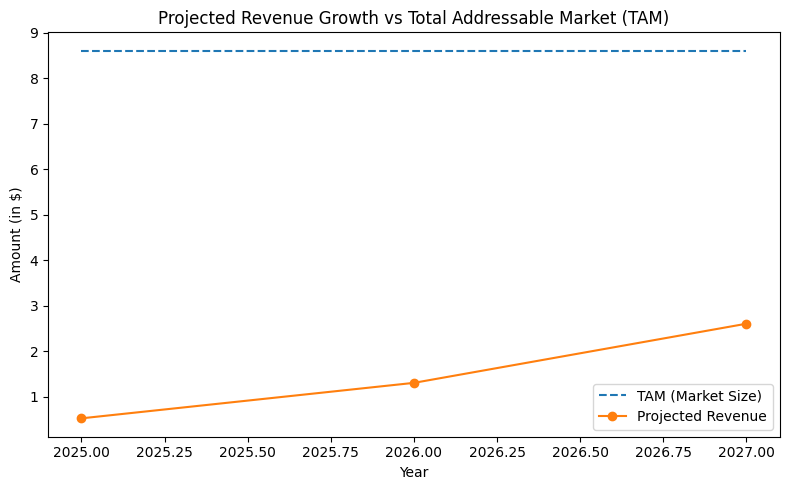

In [4]:
plt.figure(figsize=(8,5))

plt.plot(market_df['Year'], market_df['TAM'], label='TAM (Market Size)', linestyle='--')
plt.plot(market_df['Year'], market_df['Projected_Revenue'], label='Projected Revenue', marker='o')

plt.xlabel("Year")
plt.ylabel("Amount (in $)")
plt.title("Projected Revenue Growth vs Total Addressable Market (TAM)")
plt.legend()
plt.tight_layout()

plt.savefig("chart1_revenue_vs_tam.png", dpi=300, bbox_inches='tight')
plt.show()

### Insight – Growth within a Large Market
This chart shows our projected revenue growth relative to the total addressable market (TAM). Even with conservative projections, our revenue curve grows steadily while still representing a small fraction of the overall market size, highlighting both strong growth potential and significant headroom for scale—exactly what investors look for in terms of market opportunity.

## **Chart 2 – Segment Size vs Average LTV (Who Are Our Best Customers?)**

In [5]:
seg_summary = segments_df.groupby('cluster').agg(
    segment_size=('user_id', 'nunique'),
    avg_ltv=('predicted_ltv', 'mean'),
    avg_sessions=('num_sessions', 'mean'),
    avg_events=('num_events', 'mean')
).reset_index()

seg_summary


,cluster,segment_size,avg_ltv,avg_sessions,avg_events
0,0,80,115.522891,2.712500,7.000000
1,1,70,83.686260,1.285714,3.914286
2,2,50,94.691069,3.860000,3.320000


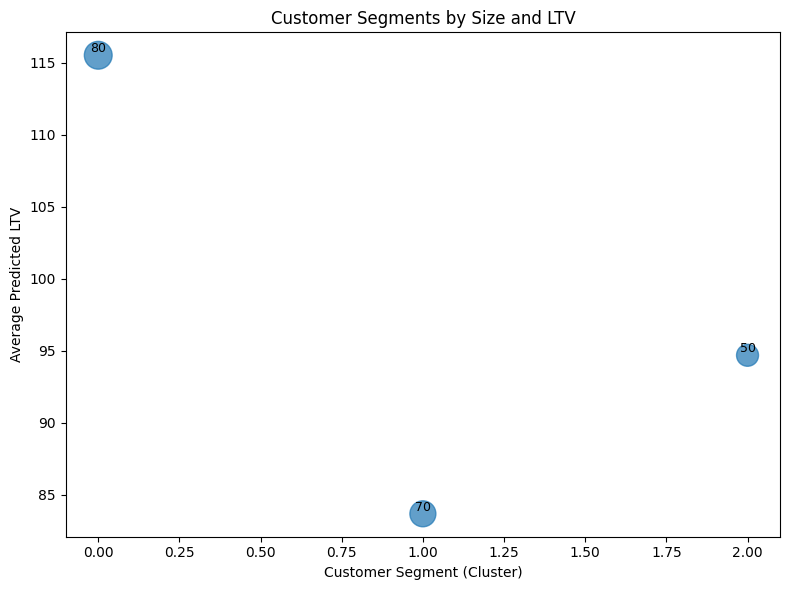

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(
    seg_summary['cluster'],
    seg_summary['avg_ltv'],
    s=seg_summary['segment_size'] * 5,
    alpha=0.7
)

for _, row in seg_summary.iterrows():
    plt.text(row['cluster'], row['avg_ltv'], f"{int(row['segment_size'])}", ha='center', va='bottom', fontsize=9)

plt.xlabel("Customer Segment (Cluster)")
plt.ylabel("Average Predicted LTV")
plt.title("Customer Segments by Size and LTV")
plt.tight_layout()

plt.savefig("chart2_segment_ltv.png", dpi=300, bbox_inches='tight')
plt.show()

### Insight – Big Segments with High LTV
This visualization highlights how each customer segment (cluster) differs in both size and predicted lifetime value (LTV). The most attractive segments are those with both high average LTV and large segment size—these are our “power users” and priority targets. For investors, this demonstrates that our growth is driven not just by more users, but by high-value, scalable customer segments.

## **Chart 3 – Revenue & Customer Growth Over Time (Traction)**

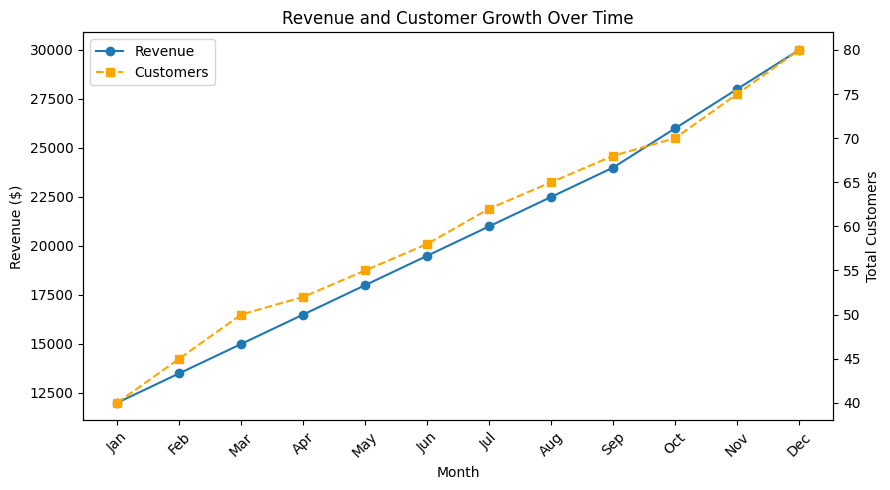

In [7]:
plt.figure(figsize=(9,5))

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(finance_df['Month'], finance_df['Revenue'], marker='o', label='Revenue')
ax2.plot(finance_df['Month'], finance_df['New Customers'], marker='s', linestyle='--', label='Customers', color='orange')

ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue ($)")
ax2.set_ylabel("Total Customers")

plt.title("Revenue and Customer Growth Over Time")
ax1.tick_params(axis='x', rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig("chart3_revenue_customers.png", dpi=300, bbox_inches='tight')
plt.show()

### Insight – Revenue Scales with Customer Growth
This chart shows that as our customer base grows, revenue increases in tandem, illustrating strong monetization of new users. For investors, this indicates that our business model scales with adoption and that we’re not just growing users without corresponding revenue.

## **Chart 4 – Unit Economics: Revenue vs Marketing Spend (Path to Efficiency)**

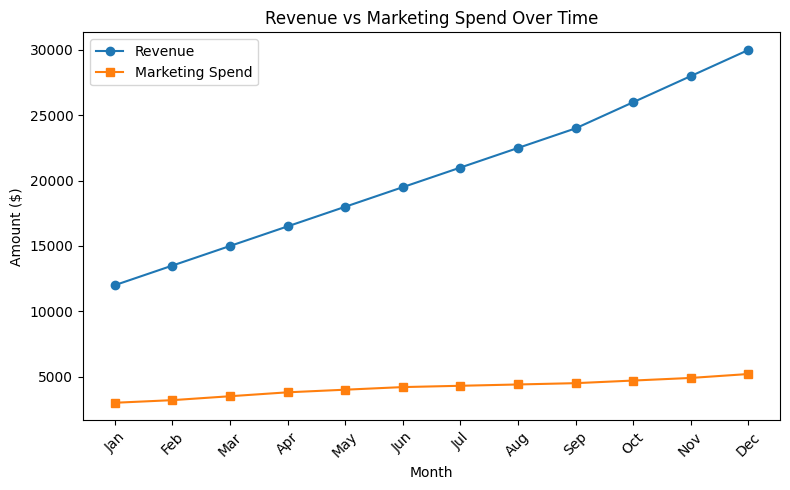

In [8]:
plt.figure(figsize=(8,5))

plt.plot(finance_df['Month'], finance_df['Revenue'], marker='o', label='Revenue')
plt.plot(finance_df['Month'], finance_df['Marketing Spend'], marker='s', label='Marketing Spend')

plt.xlabel("Month")
plt.ylabel("Amount ($)")
plt.title("Revenue vs Marketing Spend Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("chart4_revenue_vs_marketing.png", dpi=300, bbox_inches='tight')
plt.show()

### Insight – Improving Unit Economics
This chart compares revenue against marketing spend over time. The widening gap between the revenue and marketing lines indicates improving efficiency—each dollar spent on acquisition is generating more revenue over time. This is a key signal for investors that our unit economics are strengthening and the business can scale profitably.

## **Chart 5 – Product Engagement by Segment (Defensibility via Usage)**

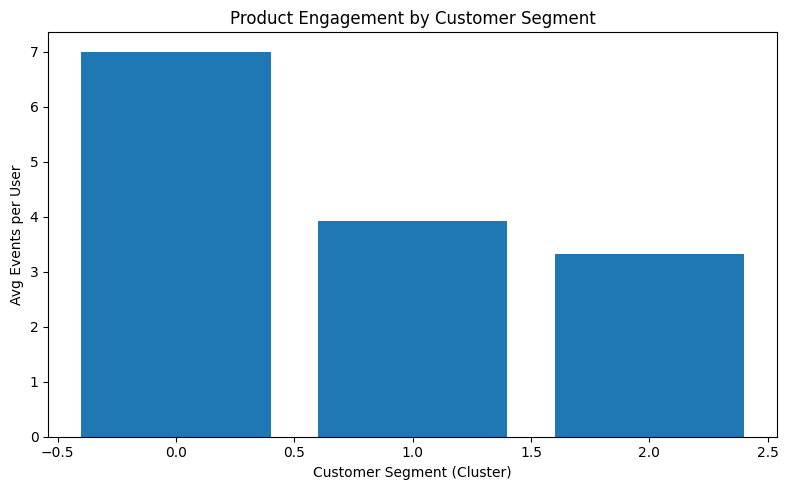

In [9]:
plt.figure(figsize=(8,5))

plt.bar(seg_summary['cluster'], seg_summary['avg_events'])

plt.xlabel("Customer Segment (Cluster)")
plt.ylabel("Avg Events per User")
plt.title("Product Engagement by Customer Segment")
plt.tight_layout()

plt.savefig("chart5_engagement_by_segment.png", dpi=300, bbox_inches='tight')
plt.show()

### Insight – Highly Engaged Core Segments
This chart reveals that certain customer segments interact with the product far more frequently than others. High engagement suggests strong product-market fit and creates defensibility: these users are harder to displace and more likely to expand usage over time. For investors, this demonstrates depth of engagement, not just surface-level signups.

## **Chart 6 – Market Share Path: SOM vs Revenue**

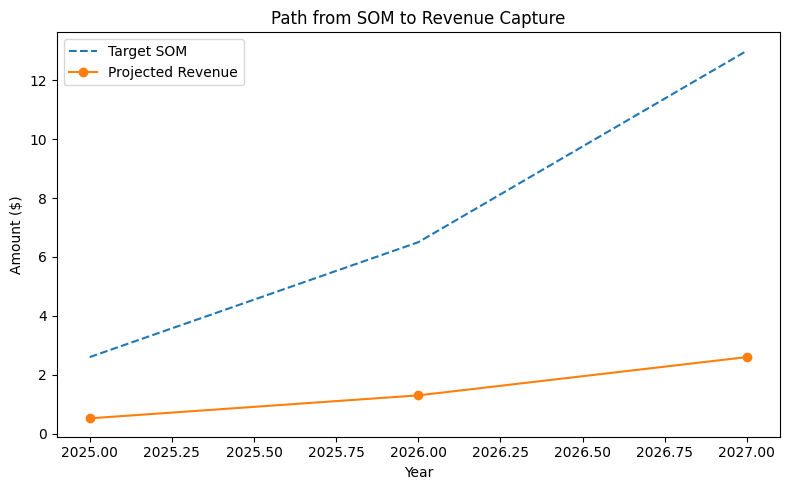

In [13]:
plt.figure(figsize=(8,5))

plt.plot(market_df['Year'], market_df['SOM'], label='Target SOM', linestyle='--')
plt.plot(market_df['Year'], market_df['Projected_Revenue'], label='Projected Revenue', marker='o')

plt.xlabel("Year")
plt.ylabel("Amount ($)")
plt.title("Path from SOM to Revenue Capture")
plt.legend()
plt.tight_layout()
plt.savefig("chart6_som_vs_revenue.png", dpi=300, bbox_inches='tight')
plt.show()

### Insight – Clear Path from Market Share to Revenue
This chart aligns our projected revenue curve with the serviceable obtainable market (SOM). It illustrates a realistic path of market capture, reinforcing that our growth story is not just theoretical but grounded in quantified market assumptions.